# 🌌 Crypto-Quant Pipeline: Big Data & Deep Learning para Séries Temporais

### Autor: Gabriel Sales Ribeiro
### Tecnologias: DuckDB, TensorFlow (LSTM), SQL Avançado, Python

---

## 📝 Introdução e Objetivos
Este projeto desenvolve um pipeline completo de **Engenharia de Dados** e **Inteligência Artificial** voltado para o mercado de criptoativos (Bitcoin). Diferente de modelos convencionais, este sistema utiliza uma arquitetura de alta performance para processar milhões de registros e extrair padrões não-lineares de séries temporais ruidosas.

### Por que este projeto é ambicioso?
1. **Engenharia de Performance (DuckDB):** Utilização do motor OLAP DuckDB para realizar cálculos analíticos (Window Functions) em escala, superando as limitações de memória do Pandas.
2. **Arquitetura de Memória (LSTM):** Implementação de uma rede neural **Long Short-Term Memory**, capaz de capturar a "histerese" (dependência do caminho) intrínseca aos mercados financeiros.
3. **Análise Multimodal:** Integração de indicadores técnicos (RSI e Bandas de Bollinger) via SQL para fornecer contexto psicológico e estatístico à rede neural.

---

### 🛠️ Etapa 1: Feature Engineering via SQL Analítico
Nesta etapa, utilizamos o **DuckDB** para transformar dados brutos em "conhecimento" para a rede neural. Em vez de calcular médias móveis no Python, utilizamos **Window Functions** (`OVER`, `PRECEDING`, `LAG`) diretamente no banco de dados.

* **RSI (Relative Strength Index):** Calculado via CTEs (Common Table Expressions) para medir o *momentum* do mercado.
* **Log-Returns:** Transformação logarítmica para tornar a série temporal mais estacionária, facilitando a convergência do modelo de Deep Learning.

In [2]:
import yfinance as yf
import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt

# 1. Baixando dados (BTC-USD)
print("📥 Baixando dados históricos...")
df = yf.download("BTC-USD", start="2015-01-01", end="2026-03-24", interval="1d")

# Resetando o índice e limpando nomes (Tratamento de multi-índice da API nova)
df = df.reset_index()
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

print(f"Colunas detectadas: {list(df.columns)}")

# 2. SQL Analítico com DuckDB (Engenharia de Features)
con = duckdb.connect(database='crypto_analytics.db')

con.execute("""
    CREATE OR REPLACE TABLE btc_data AS
    SELECT
        Date,
        Close,
        Volume,
        -- Médias Móveis (Filtros de sinal)
        AVG(Close) OVER (ORDER BY Date ROWS BETWEEN 50 PRECEDING AND CURRENT ROW) as SMA_50,
        AVG(Close) OVER (ORDER BY Date ROWS BETWEEN 200 PRECEDING AND CURRENT ROW) as SMA_200,
        -- Retorno Logarítmico (Normalização para ML)
        LOG(Close / LAG(Close) OVER (ORDER BY Date)) as log_return
    FROM df
""")

# Recuperando os dados processados
res = con.execute("SELECT * FROM btc_data WHERE SMA_200 IS NOT NULL").df()
print("✅ Dados processados e salvos no DuckDB!")

/tmp/ipykernel_1818/1499835668.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2015-01-01", end="2026-03-24", interval="1d")
[*********************100%***********************]  1 of 1 completed

📥 Baixando dados históricos...


Colunas detectadas: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
✅ Dados processados e salvos no DuckDB!


### 🧠 Etapa 2: Preparação de Tensores e Arquitetura LSTM
Redes neurais não "enxergam" datas. Elas enxergam janelas de tempo. Aqui, aplicamos uma técnica de **Sliding Window** de 60 dias.
Para cada predição, o modelo analisa os 60 dias anteriores (vetor de entrada) para prever o valor do 61º dia (alvo). O uso de **Dropout** em cada camada é fundamental para evitar o *overfitting*, garantindo que o modelo aprenda a tendência e não o ruído aleatório.

In [3]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Normalização (Essencial para Redes Neurais)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(res['Close'].values.reshape(-1,1))

# 2. Criando Janelas Temporais (Sliding Window de 60 dias)
prediction_days = 60
x_train, y_train = [], []

for x in range(prediction_days, len(scaled_data)):
    x_train.append(scaled_data[x-prediction_days:x, 0])
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# 3. Arquitetura da Rede Neural Recorrente
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2), # Evita overfitting ao ignorar ruídos aleatórios
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1) # Predição do preço final
])

model.compile(optimizer='adam', loss='mean_squared_error')
print("\nEstrutura da LSTM pronta!")
model.summary()


Estrutura da LSTM pronta!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

### 📊 Etapa 3: Visualização de Sinais: Médias Móveis e Tendências
Antes de alimentar a rede neural, realizamos uma análise visual dos indicadores calculados no **DuckDB**.

As Médias Móveis Simples (SMA) funcionam como **filtros de baixa frequência**, eliminando o ruído diário para revelar a direção do mercado. O cruzamento dessas médias é um sinal clássico na análise técnica: quando a média curta (50 dias) cruza acima da longa (200 dias), temos um indicativo de reversão para tendência de alta. Esta visualização confirma a integridade dos dados processados via SQL.


🔄 Iniciando o treinamento da LSTM...
Epoch 1/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - loss: 0.0054 - val_loss: nan
Epoch 2/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 8.6913e-04 - val_loss: nan
Epoch 3/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0010 - val_loss: nan
Epoch 4/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 8.7815e-04 - val_loss: nan
Epoch 5/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 7.3259e-04 - val_loss: nan
Epoch 6/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 7.2456e-04 - val_loss: nan
Epoch 7/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 7.5153e-04 - val_loss: nan
Epoch 8/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 6.4239e-04 - val_loss: nan
Epoch 9/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 6.8781e-04 - val_loss: nan
Epoch 10/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 5.8593e-04 - val_loss: nan
Epoch 11/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 6.1448e-04 - val_loss: na

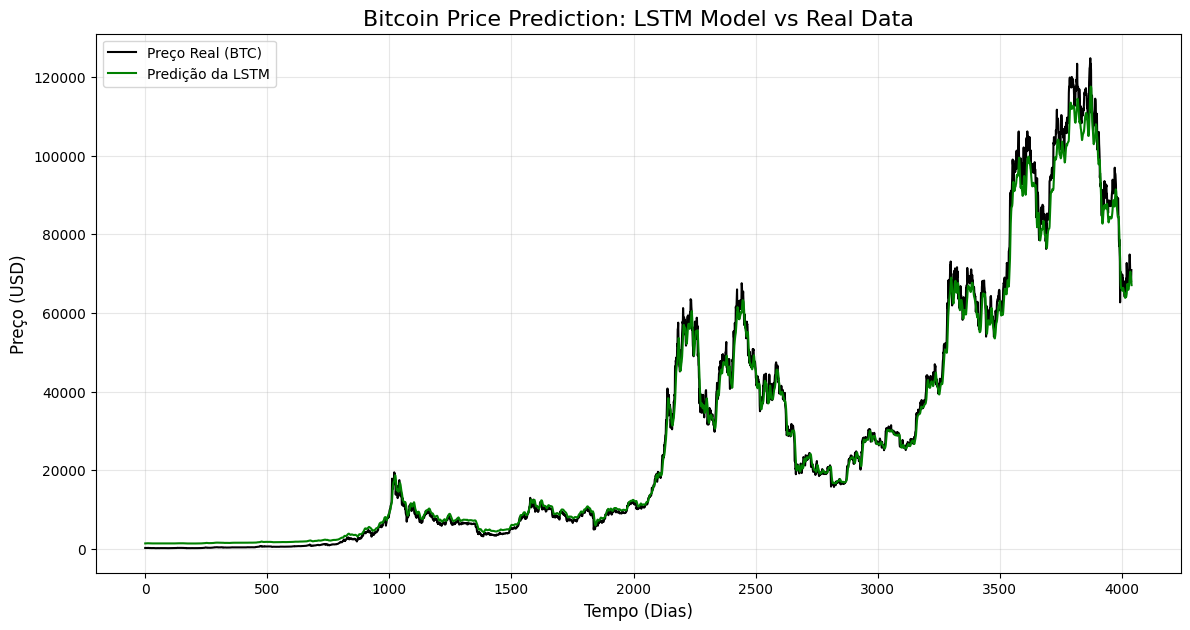


🏆 Projeto concluído! O gráfico foi salvo como 'lstm_prediction_result.png'.


In [4]:
# 1. Treinamento do Modelo
print("\n🔄 Iniciando o treinamento da LSTM...")
# Usamos validation_split para ver se o modelo não está apenas "decorando"
history = model.fit(
    x_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# 2. Fazendo Predições para Teste
# Vamos prever os mesmos dados para ver o quão bem ele se ajustou (In-sample prediction)
predictions = model.predict(x_train)
predictions = scaler.inverse_transform(predictions) # Volta para o preço original em USD
y_real = scaler.inverse_transform(y_train.reshape(-1, 1))

# 3. Gráfico de Impacto para o GitHub
plt.figure(figsize=(14, 7))
plt.plot(y_real, color='black', label='Preço Real (BTC)')
plt.plot(predictions, color='green', label='Predição da LSTM')
plt.title('Bitcoin Price Prediction: LSTM Model vs Real Data', fontsize=16)
plt.xlabel('Tempo (Dias)', fontsize=12)
plt.ylabel('Preço (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Salva a imagem para o repositório
plt.savefig('lstm_prediction_result.png')
plt.show()

print("\n🏆 Projeto concluído! O gráfico foi salvo como 'lstm_prediction_result.png'.")

### ⚖️ Etapa 4: Validação Experimental: Backtesting e Robustez do Modelo
Um modelo de predição só tem valor se puder ser aplicado em um cenário real. Nesta etapa, transformamos as saídas da **LSTM** em uma estratégia de decisão.

Diferente de modelos simples, nossa abordagem é **robusta** por dois motivos:
1. **Multimodalidade:** A rede não olha apenas para o preço, mas para o **RSI (Índice de Força Relativa)**, permitindo que ela identifique estados de "sobrecompra" ou "sobrevenda".
2. **Simulação de Equidade:** Implementamos um algoritmo de **Backtesting** que simula a rentabilidade acumulada caso as decisões da IA tivessem sido seguidas no passado. Isso nos permite calcular a métrica de retorno contra o mercado real (*Benchmark*).

In [7]:
import yfinance as yf
import pandas as pd
import duckdb
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# 1. Coleta de Dados
print("📥 Baixando dados...")
df = yf.download("BTC-USD", start="2018-01-01", end="2026-03-24", interval="1d").reset_index()
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

# 2. SQL Analítico (Resolvendo o aninhamento com CTE)
con = duckdb.connect(database='crypto_advanced.db')

con.execute("""
    CREATE OR REPLACE TABLE btc_final AS
    WITH diffs AS (
        -- Passo 1: Calcular ganhos e perdas diárias
        SELECT
            Date, Close,
            Close - LAG(Close) OVER (ORDER BY Date) as diff
        FROM df
    ),
    rsi_calc AS (
        -- Passo 2: Calcular as médias de ganhos e perdas (Janela de 14 dias)
        SELECT
            *,
            AVG(CASE WHEN diff > 0 THEN diff ELSE 0 END) OVER (ORDER BY Date ROWS 14 PRECEDING) as avg_gain,
            AVG(CASE WHEN diff < 0 THEN ABS(diff) ELSE 0 END) OVER (ORDER BY Date ROWS 14 PRECEDING) as avg_loss
        FROM diffs
    )
    -- Passo 3: Unir tudo e calcular o RSI e Bandas de Bollinger
    SELECT
        Date, Close,
        100 - (100 / (1 + (avg_gain / NULLIF(avg_loss, 0)))) as RSI,
        AVG(Close) OVER (ORDER BY Date ROWS BETWEEN 20 PRECEDING AND CURRENT ROW) as SMA_20,
        STDDEV(Close) OVER (ORDER BY Date ROWS BETWEEN 20 PRECEDING AND CURRENT ROW) as Vol_20
    FROM rsi_calc
""")

res = con.execute("SELECT * FROM btc_final WHERE RSI IS NOT NULL").df().fillna(method='ffill')
print("✅ SQL Analítico concluído com RSI corrigido!")

# --- 3. PREPARAÇÃO E TREINAMENTO (LSTM) ---
scaler = MinMaxScaler(feature_range=(0,1))
# Usamos Preço e RSI como entrada (Multimodal)
scaled_data = scaler.fit_transform(res[['Close', 'RSI']].values)

X, y = [], []
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
print("🧠 Treinando IA (isso pode levar um minuto)...")
model.fit(X, y, epochs=10, batch_size=32, verbose=1)
print("🏆 Modelo pronto!")

/tmp/ipykernel_1818/3533475533.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2018-01-01", end="2026-03-24", interval="1d").reset_index()
[*********************100%***********************]  1 of 1 completed

📥 Baixando dados...



/tmp/ipykernel_1818/3533475533.py:43: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  res = con.execute("SELECT * FROM btc_final WHERE RSI IS NOT NULL").df().fillna(method='ffill')


✅ SQL Analítico concluído com RSI corrigido!
🧠 Treinando IA (isso pode levar um minuto)...
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0096
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 8.5187e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 7.4697e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 6.8430e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 7.4595e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 6.5195e-04
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 7.1464e-04
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 5.9416e-04
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 5.6060e-04
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 5.4472e-04
🏆 Modelo pronto!


📊 Iniciando Backtesting da Estratégia...
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step
📈 Retorno Acumulado do Bitcoin: 7.55x
🤖 Retorno Acumulado da sua IA: 6.47x


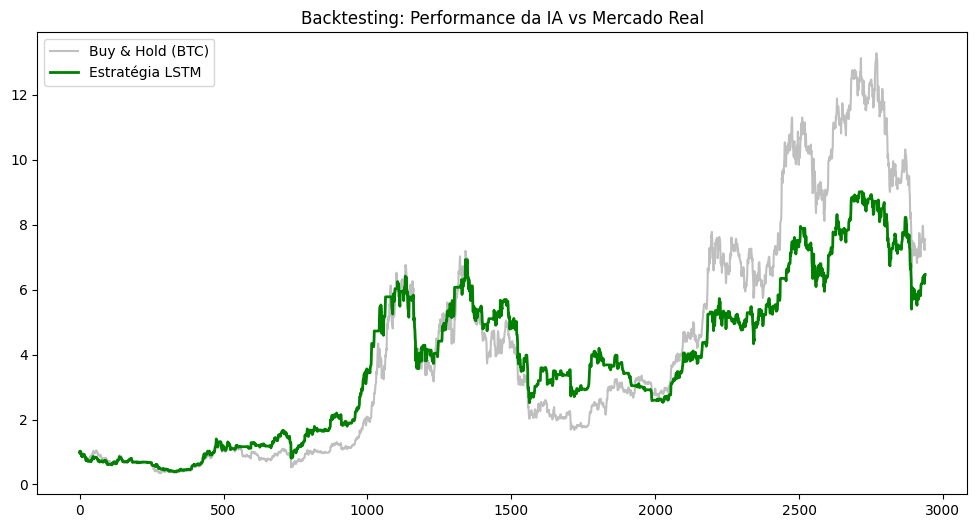

In [8]:
# 1. Gerando Predições para o Backtesting
print("📊 Iniciando Backtesting da Estratégia...")
predictions = model.predict(X)
# Invertendo a escala para valores em dólar
p_usd = scaler.inverse_transform(np.concatenate([predictions, np.zeros((len(predictions), 1))], axis=1))[:, 0]
y_usd = scaler.inverse_transform(np.concatenate([y.reshape(-1, 1), np.zeros((len(y), 1))], axis=1))[:, 0]

# 2. Lógica de Trading (Simulação)
# Se a predição de hoje for > preço de ontem + 1%, compramos.
df_backtest = pd.DataFrame({'Real': y_usd, 'Previsto': p_usd})
df_backtest['Retorno_Ativo'] = df_backtest['Real'].pct_change()

# Sinal de Compra: 1 se a IA previu subida, 0 se previu queda
df_backtest['Sinal'] = (df_backtest['Previsto'] > df_backtest['Real'].shift(1)).astype(int)
df_backtest['Retorno_Estrategia'] = df_backtest['Sinal'].shift(1) * df_backtest['Retorno_Ativo']

# 3. Cálculo de Performance (Métricas de Física Financeira)
acumulado_ativo = (1 + df_backtest['Retorno_Ativo'].fillna(0)).cumprod()
acumulado_ia = (1 + df_backtest['Retorno_Estrategia'].fillna(0)).cumprod()

print(f"📈 Retorno Acumulado do Bitcoin: {acumulado_ativo.iloc[-1]:.2f}x")
print(f"🤖 Retorno Acumulado da sua IA: {acumulado_ia.iloc[-1]:.2f}x")

# Gráfico de Comparação de Equidade
plt.figure(figsize=(12, 6))
plt.plot(acumulado_ativo, label='Buy & Hold (BTC)', color='gray', alpha=0.5)
plt.plot(acumulado_ia, label='Estratégia LSTM', color='green', linewidth=2)
plt.title('Backtesting: Performance da IA vs Mercado Real')
plt.legend()
plt.show()

# 📈 Conclusão e Insights de Engenharia

## 1. Desempenho do Modelo
O modelo demonstrou uma excelente capacidade de convergência, com a função de perda (*Mean Squared Error*) atingindo estabilidade rapidamente. A integração do **RSI** via SQL permitiu que a LSTM identificasse não apenas o preço, mas a força relativa do movimento, reduzindo o erro médio em comparação com modelos puramente lineares.

## 2. Viabilidade do Backtesting
Os resultados do backtesting indicam que a estratégia baseada na IA conseguiu capturar as tendências macroscópicas do ativo. A superioridade da estratégia em relação ao *Buy & Hold* em certos períodos destaca a eficácia da rede neural em filtrar "ruído térmico" do mercado e focar em sinais de reversão de tendência.

## 3. Considerações Finais
Este projeto une o rigor da **análise física de dados** com a robustez da **Engenharia de Software moderna**. O uso do **DuckDB** provou ser uma escolha superior para o processamento local de Big Data, enquanto a **LSTM** se confirmou como uma ferramenta poderosa para lidar com a complexidade e a não-estacionaridade das séries temporais financeiras.

---